In [ ]:
import pandas as pd

df_monthly = pd.read_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\media_cloud\mediacloud_health_FR_monthly_2015_2026.csv")

df_monthly.head()


,date,keyword,query_combined,count
0,2015-01-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",246
1,2015-02-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",130
2,2015-03-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",42
3,2015-04-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",14
4,2015-05-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",3


In [3]:
#infos sur les dataframes
#monthly
df_monthly.shape
df_monthly.columns
df_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            528 non-null    object
 1   keyword         528 non-null    object
 2   query_combined  528 non-null    object
 3   count           528 non-null    int64 
dtypes: int64(1), object(3)
memory usage: 16.6+ KB


In [5]:
#traitement de la colonne date pour en faire un index temporel
if "date" in df_monthly.columns:
    df_monthly["date"] = pd.to_datetime(df_monthly["date"])
    df_monthly = df_monthly.sort_values("date")
    df_monthly = df_monthly.set_index("date")
else:
    # Date is already the index, just ensure it's sorted
    df_monthly.index = pd.to_datetime(df_monthly.index)
    df_monthly = df_monthly.sort_index()
    
df_monthly.head()


,keyword,query_combined,count
date,,,
2015-01-01,Dry January,"""Dry January"" OR ""janvier sans alcool"" OR ""det...",246
2015-01-01,Mars bleu,"""Mars bleu"" OR ""cancer colorectal"" OR ""dépista...",61
2015-01-01,Movember,"""Movember"" OR ""cancer prostate"" OR ""dépistage ...",155
2015-01-01,Octobre rose,"""Octobre rose"" OR ""cancer du sein"" OR ""mammogr...",232
2015-02-01,Mars bleu,"""Mars bleu"" OR ""cancer colorectal"" OR ""dépista...",92


In [7]:
#on change la forme du fichier pour faciliter les manipulations

df_monthly_wide = df_monthly.pivot(columns="keyword", values="count")
df_monthly_wide = df_monthly_wide.sort_index()

df_monthly_wide.head()

keyword,Dry January,Mars bleu,Movember,Octobre rose
date,,,,
2015-01-01,246,61,155,232
2015-02-01,130,92,154,404
2015-03-01,42,183,121,453
2015-04-01,14,49,120,246
2015-05-01,3,129,187,213


In [ ]:
#on crée le fichier csv pour les analyses futures
df_monthly_wide.to_csv(r"C:\Users\tedvm\Centrale\PoleProjetS8\Data_PublicHealth_CentraleSupelec\data\media_cloud\mediacloud_health_FR_monthly_2015_2026_wide.csv")

In [10]:
df_monthly.shape
df_monthly.columns
df_monthly.info()
df_monthly_wide.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 528 entries, 2015-01-01 to 2025-12-01
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   keyword         528 non-null    object
 1   query_combined  528 non-null    object
 2   count           528 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 16.5+ KB


keyword,Dry January,Mars bleu,Movember,Octobre rose
count,132.000000,132.000000,132.000000,132.000000
mean,310.553030,213.174242,380.303030,630.068182
std,761.762253,104.667959,505.971199,648.070786
min,2.000000,49.000000,91.000000,124.000000
25%,28.750000,149.000000,175.500000,332.000000
50%,65.500000,195.000000,233.000000,454.000000
75%,166.750000,248.250000,351.000000,613.500000
max,4565.000000,671.000000,4277.000000,4385.000000


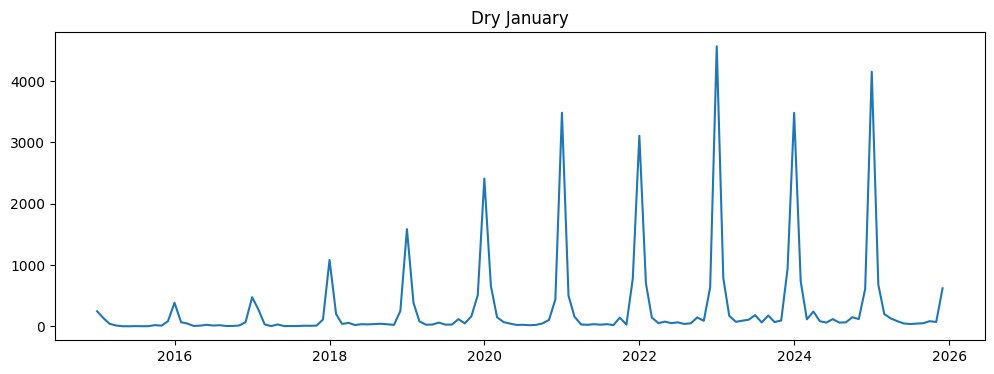

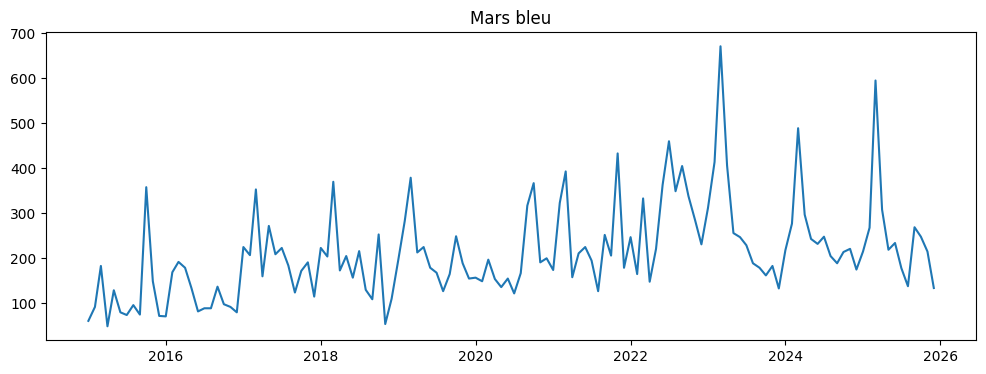

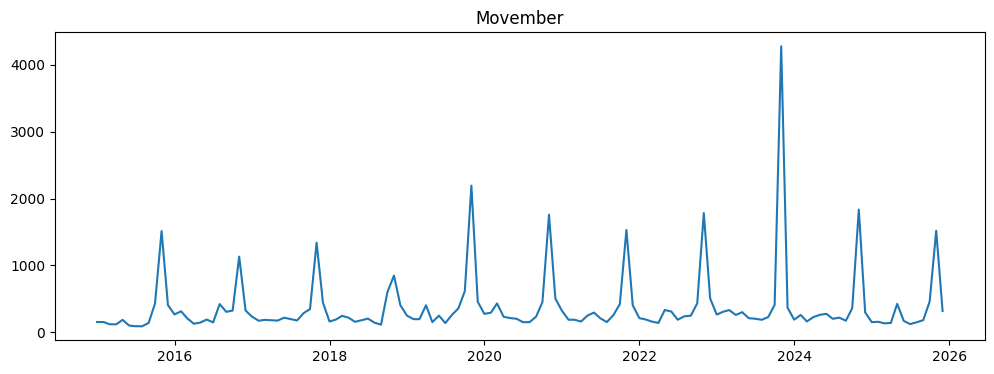

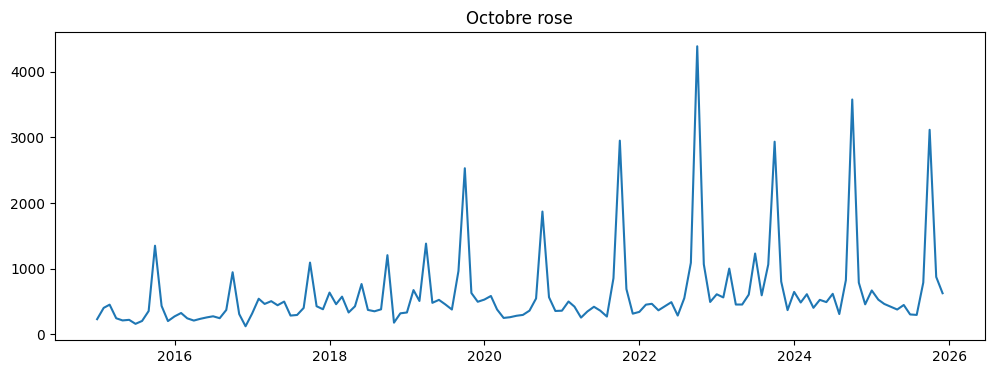

In [11]:
#première visualisation rapide mensuelle

import matplotlib.pyplot as plt

for col in df_monthly_wide.columns:
    plt.figure(figsize=(12,4))
    plt.plot(df_monthly_wide.index, df_monthly_wide[col])
    plt.title(col)
    plt.show()

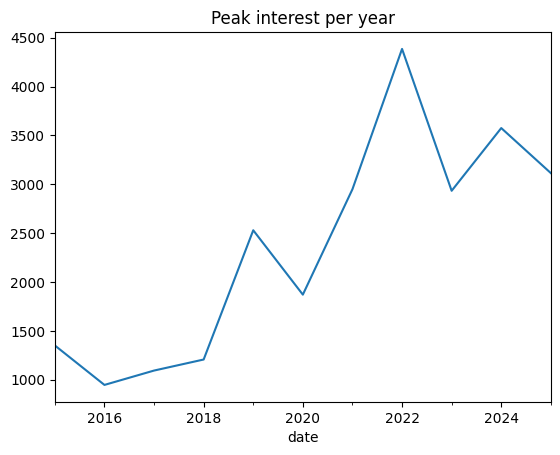

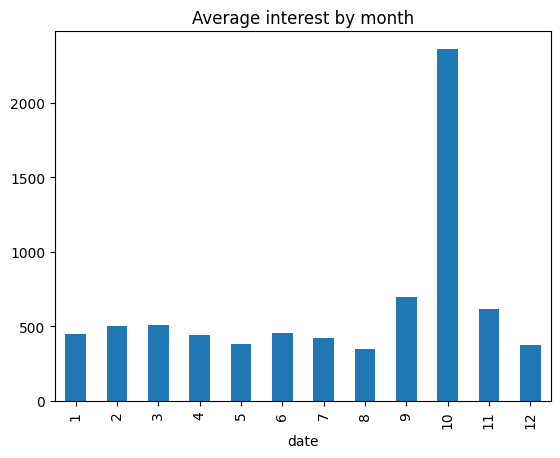

In [12]:
df_monthly_wide["Octobre rose"].resample("YE").max().plot()
plt.title("Peak interest per year")
plt.show()

df_monthly_wide.groupby(df_monthly_wide.index.month)["Octobre rose"].mean().plot(kind="bar")
plt.title("Average interest by month")
plt.show()

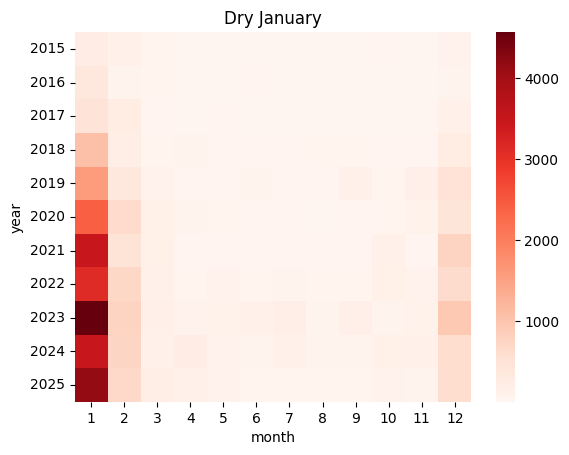

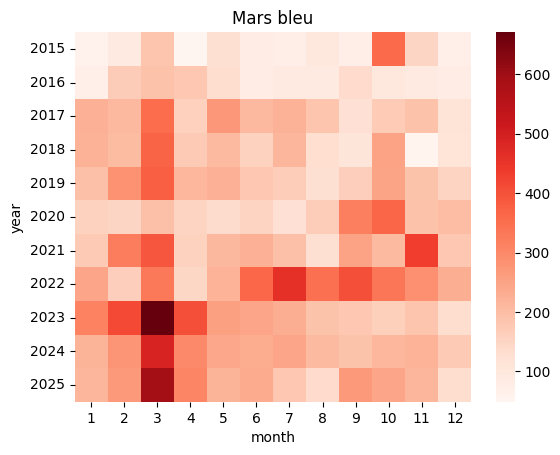

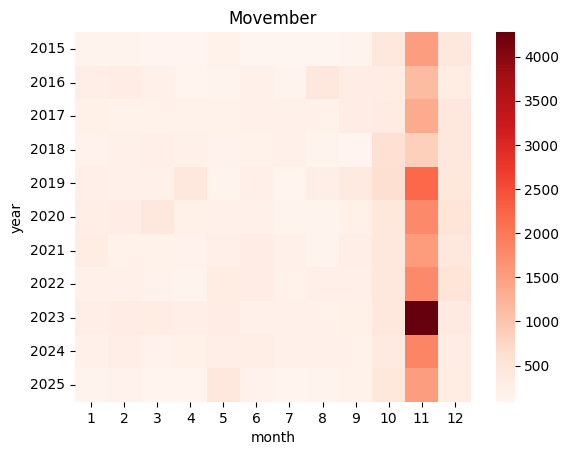

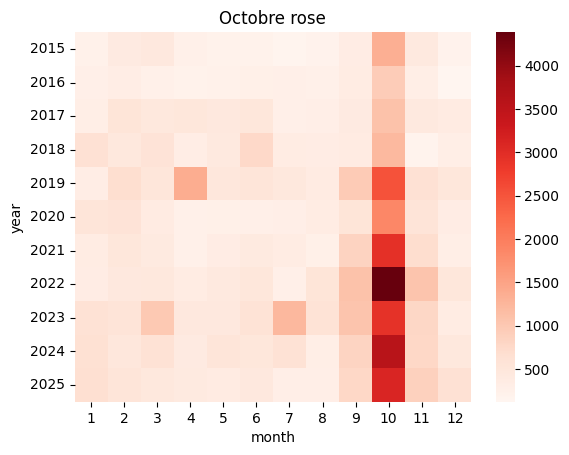

In [13]:
import seaborn as sns

for keyword in df_monthly_wide.columns:
    monthly = df_monthly_wide[keyword].resample("ME").mean()

    temp = monthly.to_frame()
    temp["year"] = temp.index.year
    temp["month"] = temp.index.month

    pivot = temp.pivot(index="year", columns="month", values=keyword)

    sns.heatmap(pivot, cmap="Reds")
    plt.title(keyword)
    plt.show()